In [1]:
import sys
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("Python:", sys.executable)
print("TensorFlow:", tf.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Python: e:\Guvi hcl file manager\GUVI_my_Fourth_project\.venv\Scripts\python.exe
TensorFlow: 2.21.0
Pandas: 3.0.6
NumPy: 2.5.3


In [2]:
import os

data_path = r"E:\Guvi hcl file manager\GUVI_my_Fourth_project\data\garbage_classification"

print("Dataset path:", data_path)
print("Path exists:", os.path.exists(data_path))

Dataset path: E:\Guvi hcl file manager\GUVI_my_Fourth_project\data\garbage_classification
Path exists: True


In [3]:
classes = sorted([
    folder
    for folder in os.listdir(data_path)
    if os.path.isdir(os.path.join(data_path, folder))
])

print("Number of classes:", len(classes))

for i, class_name in enumerate(classes, start=1):
    print(f"{i}. {class_name}")

Number of classes: 12
1. battery
2. biological
3. brown-glass
4. cardboard
5. clothes
6. green-glass
7. metal
8. paper
9. plastic
10. shoes
11. trash
12. white-glass


In [4]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

class_counts = {}

for class_name in classes:

    class_path = os.path.join(data_path, class_name)

    count = sum(
        1
        for file_name in os.listdir(class_path)
        if file_name.lower().endswith(image_extensions)
    )

    class_counts[class_name] = count

class_counts

{'battery': 945,
 'biological': 985,
 'brown-glass': 607,
 'cardboard': 891,
 'clothes': 5325,
 'green-glass': 629,
 'metal': 769,
 'paper': 1050,
 'plastic': 865,
 'shoes': 1977,
 'trash': 697,
 'white-glass': 775}

In [5]:
import pandas as pd

class_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Image_Count"]
)

class_df

,Class,Image_Count
0,battery,945
1,biological,985
2,brown-glass,607
3,cardboard,891
4,clothes,5325
5,green-glass,629
6,metal,769
7,paper,1050
8,plastic,865
9,shoes,1977


In [6]:
print("Number of classes:", len(class_df))
print("Total images:", class_df["Image_Count"].sum())

Number of classes: 12
Total images: 15515


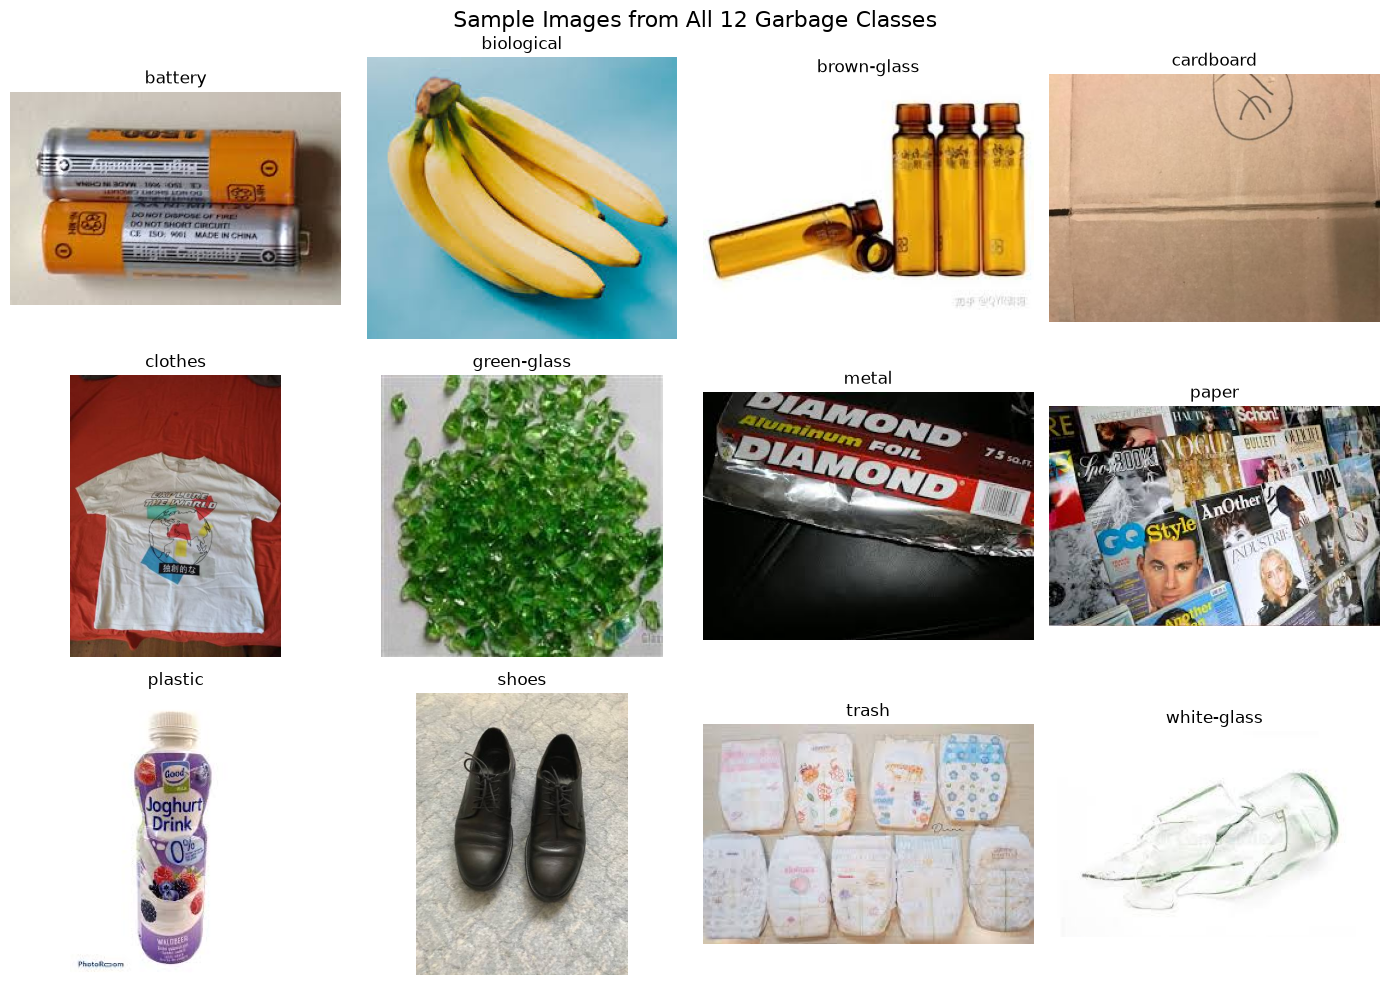

In [7]:
from PIL import Image
import matplotlib.pyplot as plt
import os

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for ax, class_name in zip(axes.flatten(), classes):

    class_path = os.path.join(data_path, class_name)

    image_files = [
        file_name
        for file_name in os.listdir(class_path)
        if file_name.lower().endswith(image_extensions)
    ]

    if image_files:
        image_path = os.path.join(
            class_path,
            image_files[0]
        )

        image = Image.open(image_path)

        ax.imshow(image)
        ax.set_title(class_name)
        ax.axis("off")

plt.suptitle(
    "Sample Images from All 12 Garbage Classes",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [8]:
image_info = []

for class_name in classes:

    class_path = os.path.join(data_path, class_name)

    for file_name in os.listdir(class_path):

        if file_name.lower().endswith(image_extensions):

            image_path = os.path.join(class_path, file_name)

            try:
                with Image.open(image_path) as img:

                    width, height = img.size

                    image_info.append({
                        "Class": class_name,
                        "File": file_name,
                        "Width": width,
                        "Height": height,
                        "Mode": img.mode
                    })

            except Exception as e:
                print("Error reading:", image_path)
                print(e)

image_df = pd.DataFrame(image_info)

print("Total images checked:", len(image_df))

Total images checked: 15515


In [9]:
print("Most common image dimensions:")

print(
    image_df[["Width", "Height"]]
    .value_counts()
    .head(20)
)

Most common image dimensions:
Width  Height
400    533       2590
512    384       2358
225    225       2004
400    534       1077
275    183        691
259    194        550
533    400        388
400    711        300
194    259        230
534    400        163
183    275        159
300    168        156
400    400        153
224    224         95
276    183         90
711    400         86
265    190         62
260    194         53
264    191         51
262    192         51
Name: count, dtype: int64


In [10]:
print("Width statistics:")
print(image_df["Width"].describe())

print("\nHeight statistics:")
print(image_df["Height"].describe())

Width statistics:
count    15515.000000
mean       349.822301
std        117.548544
min         51.000000
25%        234.000000
50%        400.000000
75%        400.000000
max        888.000000
Name: Width, dtype: float64

Height statistics:
count    15515.000000
mean       351.705833
std        149.418487
min        100.000000
25%        224.000000
50%        384.000000
75%        533.000000
max        936.000000
Name: Height, dtype: float64


In [11]:
print("Image color modes:")
print(image_df["Mode"].value_counts())

Image color modes:
Mode
RGB    15481
P         34
Name: count, dtype: int64


In [12]:
#Check for corrupted images
corrupted_images = []

for class_name in classes:

    class_path = os.path.join(data_path, class_name)

    for file_name in os.listdir(class_path):

        if file_name.lower().endswith(image_extensions):

            image_path = os.path.join(
                class_path,
                file_name
            )

            try:
                with Image.open(image_path) as img:
                    img.verify()

            except Exception:
                corrupted_images.append(image_path)

print("Number of corrupted images:", len(corrupted_images))

Number of corrupted images: 0


In [13]:
#Check whether there are extremely small images
small_images = image_df[
    (image_df["Width"] < 50) |
    (image_df["Height"] < 50)
]

print("Images smaller than 50 pixels:")
print(len(small_images))

Images smaller than 50 pixels:
0


In [14]:
small_images.head(20)

,Class,File,Width,Height,Mode


In [15]:
print("========== EDA SUMMARY ==========")

print("Number of classes:", len(classes))
print("Total images:", len(image_df))

print("\nClass distribution:")
print(class_df.to_string(index=False))

print("\nImage modes:")
print(image_df["Mode"].value_counts())

print("\nCorrupted images:", len(corrupted_images))

print("\nVery small images:", len(small_images))

========== EDA SUMMARY ==========
Number of classes: 12
Total images: 15515

Class distribution:
      Class  Image_Count
    battery          945
 biological          985
brown-glass          607
  cardboard          891
    clothes         5325
green-glass          629
      metal          769
      paper         1050
    plastic          865
      shoes         1977
      trash          697
white-glass          775

Image modes:
Mode
RGB    15481
P         34
Name: count, dtype: int64

Corrupted images: 0

Very small images: 0


In [ ]:
"""EDA Conclusion

The Garbage Classification dataset contains 15,517 images distributed across 12 waste categories: battery, biological, brown-glass, cardboard, clothes, green-glass, metal, paper, plastic, shoes, trash, and white-glass.

The dataset is imbalanced because the number of images varies considerably between classes. The clothes class contains the highest number of images, while brown-glass contains the lowest.

The images have different resolutions, so a fixed image size will be required before training the deep learning models. Most images are RGB, while a small number use palette mode. These images will be converted to RGB during preprocessing.

No corrupted images were detected, and there were no images smaller than 50 pixels in either dimension.

For model training, the images will be resized to 224 × 224 pixels and converted into a consistent 3-channel RGB format. Data augmentation and appropriate training strategies will be considered to improve generalization and address the class imbalance.

"""